In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from functools import cache

In [5]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic
from waymo_agent.graph_env.ENV import RideShareEnv
from waymo_agent.models.ppo_model import *

In [6]:
from waymo_agent.models.ppo_model import *
from waymo_agent.models.evaluate import *
from waymo_agent.models.train_utils import *

In [7]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [8]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

# Run Sim

In [9]:
env_cfg = EnvConfig(
    max_episode_steps=60 * 1,
    vehicle_per_node=0.10,
    lambda_per_node=0.05,
    max_pending_requests=100,
    max_new_requests_per_step=20,
)
plt_cfg = PlotConfig()
env_model = RideShareEnv(env_cfg, plt_cfg)

Assigned lambda values to nodes. Total lambda: 39.1000 (target: 39.1000)


In [10]:
GAMMA = get_gamma_from_half_life(env_cfg.max_episode_steps // 2)
round(GAMMA, 5)

0.97716

In [11]:
def discounted_rewards(rewards: np.ndarray, gamma: float = 0.997) -> np.ndarray:
    """
    Discount rewards using discount factor gamma.
    """
    disc_schedule = exp_decay_half_life(len(rewards), gamma=gamma)
    return rewards * disc_schedule


def get_act_dict(agents: tuple[PricingAgent, DispatchAgent, RepositionAgent], obs: ObservationDict) -> ActionDict:
    price_agent, dispatch_agent, reposition_agent = agents
    prices = price_agent.price(obs)
    dispatch_actions = dispatch_agent.dispatch(obs)
    reposition_actions = reposition_agent.reposition(obs)

    action_agent: ActionDict = {
        "prices": prices,
        "dispatch": dispatch_actions,
        "reposition": reposition_actions,
    }
    return action_agent

In [12]:
@torch.no_grad()
def run_model_simulation(
    env_curr: RideShareEnv,
    model: RideShareActorCritic,
    num_iter: int = 1,
    gamma: float = GAMMA,
    deterministic: bool = False,
):
    """
    Returns:
      REWARDS: list[episode][t] discounted reward_t
      OBS:     list[episode][t] obs dict (numpy)
      ACT:     list[episode][t] action dict (numpy)
    """
    model.eval()

    REWARDS: list[np.ndarray] = []
    OBS: list[list[dict[str, np.ndarray]]] = []
    ACT: list[list[dict[str, np.ndarray]]] = []
    TERMINATED: list[bool] = []
    TRUNCATED: list[bool] = []

    for i in tqdm(range(num_iter), desc="model rollout"):
        # tqdm.write(f"Starting episode {i+1}/{num_iter}...")
        obs_np, _info = env_curr.reset()
        terminated = False
        truncated = False
        done = False

        rews_raw: list[float] = []
        obs_list: list[dict[str, np.ndarray]] = []
        act_list: list[dict[str, np.ndarray]] = []

        while not done:
            # tqdm.write(f"Step {env_curr.current_step}/{env_curr.config.max_episode_steps}")
            obs_list.append(obs_np)

            obs_t = obs_pd_to_torch(obs_np)

            act_t = model.act(obs_t, deterministic=deterministic)
            act_np = action_torch_to_numpy(act_t)
            env_curr._validate_action(act_np)
            act_list.append(act_np)

            obs_np, reward, terminated, truncated, _info = env_curr.step(act_np)  # type: ignore[arg-type]
            # print(f"Reward: {reward}")
            rews_raw.append(float(reward))
            done = bool(terminated) or bool(truncated)

        rews = discounted_rewards(np.array(rews_raw, dtype=np.float32), gamma=gamma)
        REWARDS.append(rews)
        OBS.append(obs_list)
        ACT.append(act_list)
        TERMINATED.append(terminated)
        TRUNCATED.append(truncated)

    return REWARDS, OBS, ACT, TERMINATED, TRUNCATED

In [15]:
model = RideShareActorCritic(env_model)
cfg_ppo = PPOTrainConfig(total_steps=500, eval_every_updates=1, eval_episodes=2, debug=True)

In [16]:
REWARDS, OBS, ACT, TERMINATED, TRUNCATED = run_model_simulation(env_model, model, num_iter=1)

model rollout:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
TERMINATED, TRUNCATED

([False], [True])

In [18]:
env_model._rewards

{'penalty_multiple_dispatch_assignment': -2.2,
 'penalty_assign_to_unavailable_vehicle': 5.6,
 'distance_penalty_xy_normed': 0.0,
 'penalty_rejected': np.float64(-0.0),
 'penalty_expire': np.float64(-0.0),
 'ride_reward_total': np.float64(-16.52325709350407)}

In [19]:
# import importlib
# import waymo_agent.data_classes.enriched_df_base

# _ = importlib.reload(waymo_agent.data_classes.enriched_df_base)

## NN Actor-Critic

In [20]:
model = RideShareActorCritic(env_model)
cfg_ppo = PPOTrainConfig(total_steps=120, gamma=GAMMA, log_every_updates=1)

In [21]:
pprint(cfg_ppo)

PPOTrainConfig(total_steps=120,
               debug=False,
               gamma=0.9771599684342459,
               gae_lambda=0.95,
               lr=0.0003,
               clip_eps=0.2,
               vf_coef=0.5,
               ent_coef=0.01,
               max_grad_norm=0.5,
               update_epochs=4,
               minibatch_size=256,
               deterministic_eval=True,
               log_every_updates=1,
               eval_episodes=2,
               eval_every_updates=5,
               patience=20,
               min_delta=0.001,
               save_best=True)


In [22]:
pprint(env_cfg)

EnvConfig(map_name='manhattan-sparse-782-nodes-enriched.graphml',
          map_dir=PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps'),
          vehicle_per_node=0.1,
          max_vehicles=50,
          time_step_delta=datetime.timedelta(seconds=60),
          max_episode_steps=60,
          day_per_week=7,
          hours_per_day=24,
          lambda_per_node=0.05,
          lambda_variation_coef=2.0,
          max_new_requests_per_step=20,
          max_pending_requests=100,
          max_wait_time_minutes=15,
          max_price=inf,
          invalid_id=-1,
          acceptance_margin_weight=-2.0,
          acceptance_supply_demand_weight=3.0,
          battery_consumption_per_km=0.01,
          charge_rate_per_minute=0.12,
          min_battery_for_assignment=0.2,
          chargable_node_ratio=0.01,
          max_chargers_per_node=1,
          penalty_rejected=-0.01,
          penalty_expire=-0.5,
          penalty_overflow=0,
          reward_frac_ride_completion=15.

In [23]:
obs, _ = env_model.reset()

In [24]:
veh, req, rides = get_obs_tuple(env_model)

In [25]:
dtt([veh, req, rides], how="head")

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 int64 
 float32 
 float32 
 float32 
 int64 
 int64 
 
 
 
 
 0 
 0 
 0.036 
 -0.150 
 0.874 
 0 
 -1 
 
 
 1 
 1 
 -0.321 
 -0.726 
 0.664 
 0 
 -1 
 
 
 2 
 2 
 0.081 
 -0.348 
 0.670 
 0 
 -1 
 
 
 3 
 3 
 -0.106 
 -0.231 
 0.971 
 0 
 -1 
 
 
 4 
 4 
 -0.383 
 0.053 
 0.789 
 0 
 -1 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 
 
 
 int64 
 datetime64[ns] 
 int64 
 float64 
 float64 
 float64 
 float64 
 timedelta64[ns] 
 timedelta64[ns] 
 int64 
 int64 
 float64 
 float64 
 int64 
 float64 
 float64 
 object 
 int64 
 int64 
 float64 
 float64 
 
 
 
 
 0 
 1299 
 2025-01-04 16:37:49.057116 
 46696 
 -1.382 
 2.084 
 5.147 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 12154605956 
 -0.383 
 0.053 
 1918039864 
 -0.204 
 -0.483 
 [12154605956, 10858288590, 246650510, 246580797, 42427494, 246580466, 42430589, 42437914, 42437909, 42435624, 42432214, 42430828, 42430237, 4321748237, 4202908174, 42428447, 42445511, 42437612, 1918039864] 
 12154605956 
 10858288590 
 0.0 
 5147.375 
 
 
 1 
 1298 
 2025-01-04 16:37:49.057116 
 2289 
 1.108 
 1.597 
 1.274 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 1061531454 
 -0.004 
 0.451 
 9170816532 
 -0.038 
 0.282 
 [1061531454, 42428653, 42428634, 9177424867, 42428595, 1061531707, 6173564360, 9170816532] 
 1061531454 
 42428653 
 0.0 
 1274.483 
 
 
 2 
 1297 
 2025-01-04 16:37:49.057116 
 48767 
 -1.058 
 1.679 
 8.649 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 278638234 
 -0.359 
 -0.682 
 42440397 
 0.249 
 0.344 
 [278638234, 486819535, 4561384853, 42427316, 42427324, 42427327, 42430041, 1918039897, 42445511, 42448693, 4597668041, 561042190, 42445365, 42437644, 42452973, 42443950, 42437358, 42432693, 42434072, 42432580, 42440153, 42436700, 42450426, 42432818, 5706568771, 4347534783, 42455662, 42447228, 42436475, 42440397] 
 278638234 
 486819535 
 0.0 
 8649.099 
 
 
 3 
 1296 
 2025-01-04 16:37:49.057116 
 17785 
 -2.453 
 1.527 
 8.984 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 278608718 
 -0.321 
 -0.726 
 42428634 
 -0.038 
 0.373 
 [278608718, 278609863, 3884569924, 3884569931, 42437749, 588455743, 588455742, 1773066054, 541467364, 5161246307, 42440804, 42427316, 5706569898, 42428433, 42440829, 4143859873, 3788379733, 42440838, 42423456, 42445574, 42430761, 42430828, 42432214, 42435624, 42435644, 42435646, 42435650, 42435663, 42432700, 42435675, 42432589, 42435684, 42435705, 42435707, 42435714, 1825841704, 1825841655, 42428575, 42428588, 9915469771, 42428595, 9177424867, 42428634] 
 278608718 
 278609863 
 0.0 
 8984.118 
 
 
 4 
 1295 
 2025-01-04 16:37:49.057116 
 39 
 -3.520 
 2.117 
 9.438 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 246649429 
 -0.474 
 -0.254 
 7076060066 
 0.494 
 0.594 
 [246649429, 42454328, 246648219, 42445766, 42437914, 42437693, 1701844618, 42437670, 42434427, 9971300853, 427842070, 42444964, 4491359481, 42445001, 42437368, 42432703, 42445018, 42432594, 42440163, 1815133244, 42445033, 42445037, 1241742563, 42428575, 1061531509, 5706568625, 7802856365, 7802856352, 42435275, 42427915, 7106818626, 42424439, 42431293, 42443263, 42443264, 42450456, 42446138, 7076060066] 
 246649429 
 42454328 
 0.0 
 9437.744 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 int64 
 int64 
 int64 
 float32 
 float32 
 int64 
 float32 
 float32 
 float32 
 float32 
 float32 
 float32 
 float32 
 object 
 int64 
 int64 
 float32 
 bool 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.0 


In [27]:
from waymo_agent.models.train_ppo import train_ppo


model, logs = train_ppo(env_model, model, train_cfg=cfg_ppo, save_path=MODEL_WEIGHT_DIR / "ppo_model_final.pt")

PPO steps:   0%|          | 0/120 [00:00<?, ?step/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

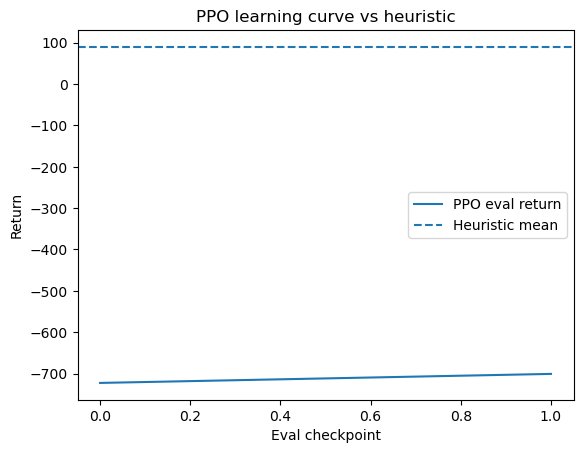

In [28]:
plot_learning_curve_vs_baseline(logs, heur_mean=env_cfg.max_episode_steps * 1.5)

In [29]:
model = RideShareActorCritic(env_model)
cfg_ppo = PPOTrainConfig(total_steps=120, gamma=GAMMA, log_every_updates=1)

In [30]:
_ = model.forward(obs_pd_to_torch(obs))

In [31]:
out = model.act(obs_pd_to_torch(obs), deterministic=False)

In [32]:
out

{'prices': tensor([1.0000e+00, 2.9999e+04, 1.0000e+00, 1.0000e+00, 1.0000e+00, 3.1399e+04,
         4.9610e+02, 1.0316e+04, 5.3660e+04, 2.1844e+04, 4.7350e+04, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.8282e+04,
         1.0000e+00, 1.0406e+04, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+0

In [33]:
env_model.step()

TypeError: RideShareEnv.step() missing 1 required positional argument: 'action'